In [1]:
#importing the necessary libraries
import numpy as np
import pandas as pd
import tensorflow as tf 
import matplotlib.pyplot as plt
import seaborn as sns

#import NLP libraries
from collections import Counter
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
#Download stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

#import text vectorization
from tensorflow.keras.layers import TextVectorization

#Build deeplearning model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Bidirectional,Dense,Embedding
import pickle

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\evm88\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
#Loading the dataset
df = pd.read_csv(r"D:\Guvi\Mini-project_5(CommentToxicity)\commentToxicity\train.csv")
df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


Inspecting the dataset

In [3]:
#First 5 rows
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
#checking the rows and columns count
df.shape

(159571, 8)

In [5]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [7]:
#check null values
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

The dataset does not contain missing values in any column.

Therefore, no missing value treatment or imputation was required during preprocessing.

In [8]:
#check duplicate rows
df.duplicated().sum()

0

No duplicate rows were found in the dataset.

This ensures that repeated comments do not bias the model during training.

In [9]:
#Understand the target columns
target_columns = ['toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate']

df[target_columns].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

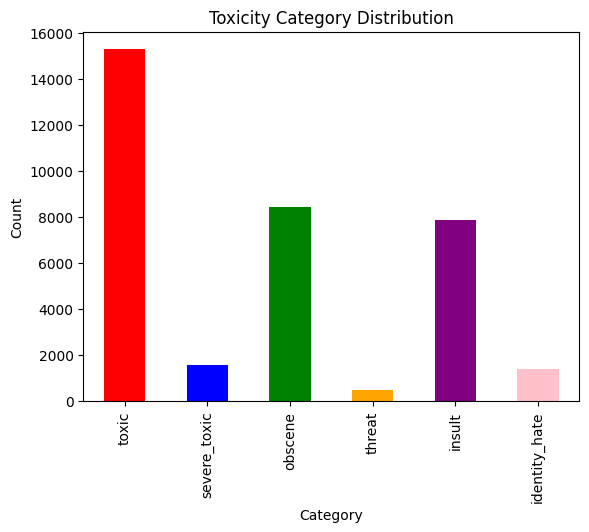

In [10]:
#Plotting

toxic_counts = df[target_columns].sum()


bar_colors = ['red', 'blue', 'green', 'orange','purple','pink']
toxic_counts.plot(kind='bar',color=bar_colors)
plt.title("Toxicity Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

This bar chart shows the distribution of toxicity categories in the dataset.

We can observe that the 'toxic' category has the highest number of comments, while categories like 'obscene' and 'insult' have comparatively fewer samples.

This indicates that the dataset is imbalanced, which is common in real-world classification problems.

In [11]:

# Correlation matrix

correlation = df[target_columns].corr()

correlation

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,1.000000,0.308619,0.676515,0.157058,0.647518,0.266009
severe_toxic,0.308619,1.000000,0.403014,0.123601,0.375807,0.201600
obscene,0.676515,0.403014,1.000000,0.141179,0.741272,0.286867
threat,0.157058,0.123601,0.141179,1.000000,0.150022,0.115128
insult,0.647518,0.375807,0.741272,0.150022,1.000000,0.337736
identity_hate,0.266009,0.201600,0.286867,0.115128,0.337736,1.000000


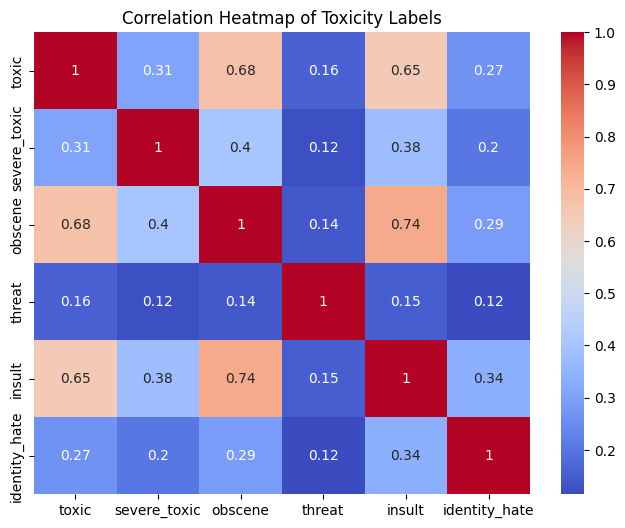

In [12]:
# Plotting heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap of Toxicity Labels")

plt.show()

The heatmap shows the correlation between different toxicity labels.

We observe that some categories such as 'toxic', 'obscene', and 'insult' are highly correlated, meaning they often occur together in comments.

Lower correlation values indicate weaker relationships between certain toxicity classes.

In [13]:
#Creating comment length column and display statistics
df["comment_length"] = df["comment_text"].apply(len)
df["comment_length"].describe()

count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: comment_length, dtype: float64

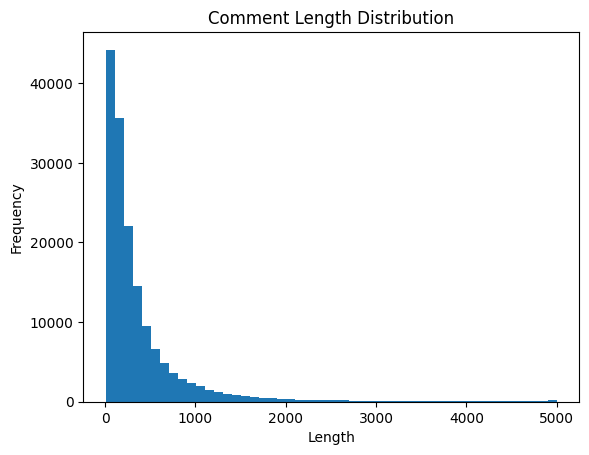

In [14]:
#visualization
plt.hist(df["comment_length"],bins=50)
plt.title("Comment Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

This graph shows the distribution of comment lengths in the dataset.

Most comments are relatively short, while only a few comments contain very long text.

Understanding comment length helps in choosing suitable sequence length during text vectorization.

In [15]:
# Creating total toxicity column

df['total_labels'] = df[['toxic',
                         'severe_toxic',
                         'obscene',
                         'threat',
                         'insult',
                         'identity_hate']].sum(axis=1)

# Toxic vs non-toxic

toxic_vs_clean = df['total_labels'].apply(
    lambda x: 'Toxic' if x > 0 else 'Non-Toxic'
).value_counts()

toxic_vs_clean

total_labels
Non-Toxic    143346
Toxic         16225
Name: count, dtype: int64

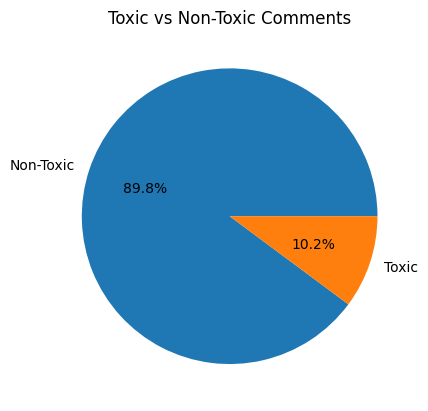

In [16]:
toxic_vs_clean.plot(kind='pie', autopct='%1.1f%%')

plt.title("Toxic vs Non-Toxic Comments")

plt.ylabel("")

plt.show()

The pie chart shows the distribution of toxic and non-toxic comments in the dataset.

Most comments belong to the non-toxic category, while toxic comments form a smaller portion of the dataset.

This imbalance is common in real-world text classification problems.

In [17]:
#Displaying sample comments
df['comment_text'].head()

0    Explanation\nWhy the edits made under my usern...
1    D'aww! He matches this background colour I'm s...
2    Hey man, I'm really not trying to edit war. It...
3    "\nMore\nI can't make any real suggestions on ...
4    You, sir, are my hero. Any chance you remember...
Name: comment_text, dtype: object

In [18]:
#text cleaningfunction

def clean_text(text):

    #convert the text to lower case
    text = text.lower()

    #remove URLs 
    text = re.sub(r'http\S+','',text)

    #remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]','',text)

    #remove extra spaces
    text = re.sub(r'\s+',' ',text).strip()

    #remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)



In [19]:
#Applying cleaning function

df['clean_comment'] = df['comment_text'].apply(clean_text)

#Display original and cleaned text
df[['comment_text','clean_comment']].head()

,comment_text,clean_comment
0,Explanation\nWhy the edits made under my usern...,explanation edits made username hardcore metal...
1,D'aww! He matches this background colour I'm s...,daww matches background colour im seemingly st...
2,"Hey man, I'm really not trying to edit war. It...",hey man im really trying edit war guy constant...
3,"""\nMore\nI can't make any real suggestions on ...",cant make real suggestions improvement wondere...
4,"You, sir, are my hero. Any chance you remember...",sir hero chance remember page thats


Text preprocessing removed unwanted elements such as punctuation, URLs, stopwords, and special characters.

This improves text quality and helps the deep learning model learn meaningful patterns more effectively.

In [20]:
# Joining all cleaned text

all_words = " ".join(df['clean_comment']).split()

# Counting words

word_counts = Counter(all_words)

# Top 20 words

word_counts.most_common(20)

[('article', 55439),
 ('page', 45669),
 ('wikipedia', 35602),
 ('talk', 31518),
 ('please', 29616),
 ('would', 29212),
 ('one', 28069),
 ('like', 27706),
 ('dont', 26102),
 ('see', 21490),
 ('also', 20549),
 ('think', 20041),
 ('im', 19476),
 ('know', 18994),
 ('people', 17703),
 ('edit', 17594),
 ('articles', 17528),
 ('use', 16323),
 ('may', 15567),
 ('time', 15418)]

Knowing about Non-Toxic words

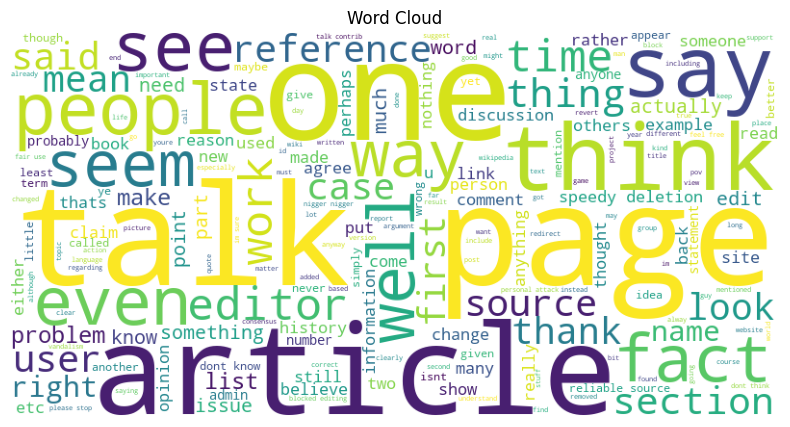

In [21]:
# Joining text

text = " ".join(df['clean_comment'])

# Creating word cloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

# Display

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Word Cloud")

plt.show()

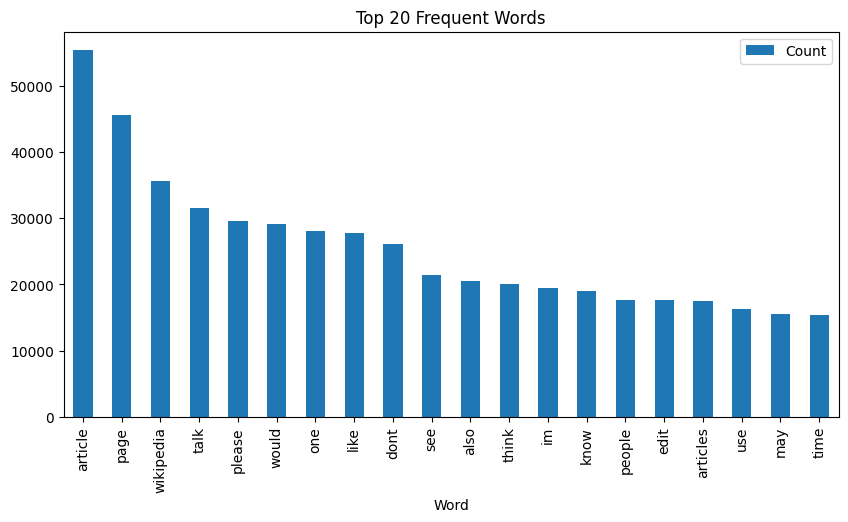

In [22]:
top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=['Word', 'Count']
)

top_words.plot(
    x='Word',
    y='Count',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 20 Frequent Words")

plt.show()

The non-toxic word cloud displays the most common words used in normal comments.

Compared to toxic comments, these words are generally more neutral and conversational.

This helps understand the difference in language patterns between toxic and non-toxic comments.

Knowing about Toxic words

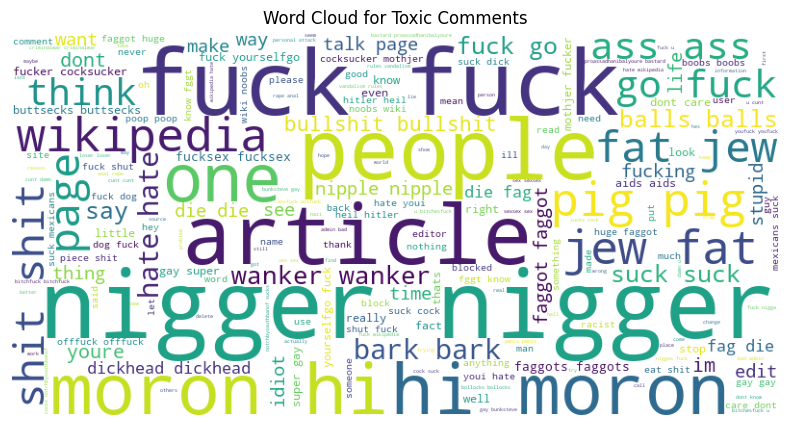

In [23]:
# Joining toxic comments

toxic_text = " ".join(
    df[df['toxic'] == 1]['clean_comment']
)

# Creating word cloud

toxic_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(toxic_text)

# Displaying

plt.figure(figsize=(10,5))

plt.imshow(toxic_wordcloud)

plt.axis('off')

plt.title("Word Cloud for Toxic Comments")

plt.show()

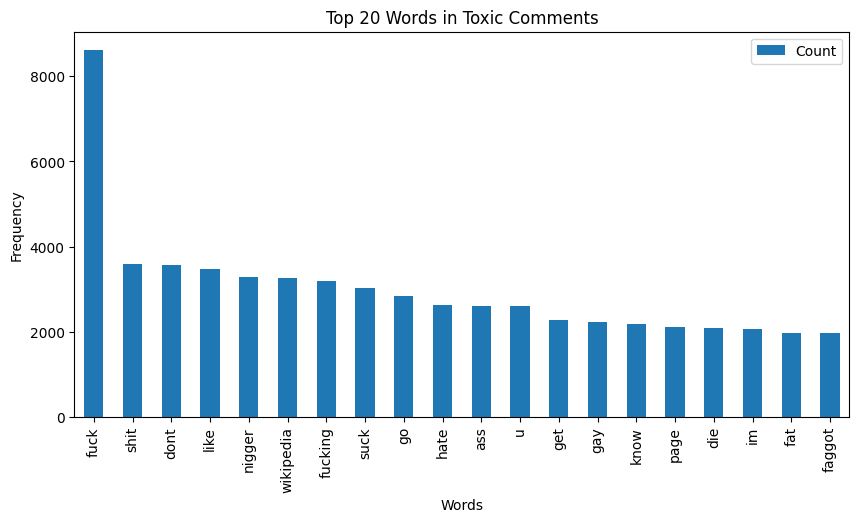

In [24]:


# Selecting toxic comments only

toxic_text = df[df['toxic'] == 1]['clean_comment']

# Joining all toxic comments

toxic_words = " ".join(toxic_text).split()

# Counting words

toxic_word_counts = Counter(toxic_words)

# Top 20 toxic words

top_toxic_words = pd.DataFrame(
    toxic_word_counts.most_common(20),
    columns=['Word', 'Count']
)

# Plotting

top_toxic_words.plot(
    x='Word',
    y='Count',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 20 Words in Toxic Comments")

plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

The word cloud visualizes the most frequently occurring words in toxic comments.

Words appearing larger indicate higher frequency.

This helps identify commonly used offensive or abusive words in toxic comments.

Features and target seperation

In [25]:
#input feature
X = df['clean_comment']

#Target columns
y = df[['toxic', 
        'severe_toxic',
        'obscene',
        'threat',
        'insult',
        'identity_hate']]


Text vectorization

Create vectorizer

In [26]:
#maximum vocabulary size
MAX_FEATURES = 200000

#Text vectorization layer
vectorizer = TextVectorization(
    max_tokens = MAX_FEATURES,
    output_sequence_length =200,
    output_mode = 'int' 
)

Train vectorizer on  text

In [27]:
#Learning vocabulary from text
vectorizer.adapt(X.values)

Convert text into Numbers

In [28]:
#vectorizing text

vectorized_text = vectorizer(X.values)
vectorized_text

<tf.Tensor: shape=(159571, 200), dtype=int64, numpy=
array([[   524,     45,     48, ...,      0,      0,      0],
       [192272,   2321,   1275, ...,      0,      0,      0],
       [   312,    326,     14, ...,      0,      0,      0],
       ...,
       [ 30736,   7118,    267, ...,      0,      0,      0],
       [   417,      9,    109, ...,      0,      0,      0],
       [    51,     10,     13, ...,      0,      0,      0]], dtype=int64)>

Create Tensorflow dataset

In [29]:
#Creating  Tensorflow dataset

dataset = tf.data.Dataset.from_tensor_slices((vectorized_text,y))


In [30]:
#optimizing the dataset

dataset = dataset.cache()
dataset = dataset.shuffle(160000)
dataset = dataset.batch(16)
dataset = dataset.prefetch(8)

#calculating train size
train_size = int(len(dataset) * 0.8)

#Training data
train_dataset = dataset.take(train_size)

#Validation data
val_dataset = dataset.skip(train_size)

Create  Model

In [31]:
#Building LSTM Model 
model = Sequential()

#Embedding layer
model.add(Embedding(200001, 32))

#Bidirectional LSTM
model.add(Bidirectional(LSTM(32,activation='tanh')))

#Dense Layers
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))

#Output layer
model.add(Dense(6, activation='sigmoid'))

In [32]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 32)          6400032   
                                                                 
 bidirectional (Bidirection  (None, 64)                16640     
 al)                                                             
                                                                 
 dense (Dense)               (None, 128)               8320      
                                                                 
 dense_1 (Dense)             (None, 256)               33024     
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 6)                 774       
                                                        

Compile Model

In [33]:
#compiling model

model.compile(
    loss = 'BinaryCrossentropy',
    optimizer = 'Adam',
    metrics = ['accuracy']
)

In [34]:
history = model.fit(
    train_dataset,
    epochs=2,
    validation_data = val_dataset
)

Epoch 1/2

7979/7979 [==============================] - 3770s 472ms/step - loss: 0.0605 - accuracy: 0.9877 - val_loss: 0.0437 - val_accuracy: 0.9937
Epoch 2/2
7979/7979 [==============================] - 2494s 313ms/step - loss: 0.0437 - accuracy: 0.9939 - val_loss: 0.0381 - val_accuracy: 0.9926


Save model

In [35]:
#saving trained model
model.save("toxicity_model.h5")

d:\Guvi\Mini-project_5(CommentToxicity)\commentToxicity\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Save vectorizer

In [36]:
#saving vectorizer
#Save vectorizer config and weights

vectorizer_data = {
    "config": vectorizer.get_config(),
    "weights": vectorizer.get_weights()
}
with open("vectorizer.pkl","wb") as f:
    pickle.dump(vectorizer_data, f)

Test prediction

In [37]:
#Sample comment
sample_text = "I hate you stupid idiot"

#Vectorize text
sample_vector = vectorizer([sample_text])

#Predict
prediction = model.predict(sample_vector)
print(prediction)

1/1 [==============================] - 2s 2s/step
[[0.99919504 0.27778634 0.9744018  0.04196982 0.918912   0.18012097]]


In [38]:
#convert probabilities
(prediction > 0.5).astype(int)

array([[1, 0, 1, 0, 1, 0]])

test data

In [39]:
#load the test data 
test_df = pd.read_csv(r"D:\Guvi\Mini-project_5(CommentToxicity)\commentToxicity\test.csv")


In [40]:
test_df.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [41]:
test_df.columns

Index(['id', 'comment_text'], dtype='object')

Cleaning the test comments

In [42]:
#clean comments
test_df['clean_comment'] = test_df["comment_text"].apply(clean_text)

#Display the cleaned text 
test_df[["comment_text","clean_comment"]].head()

,comment_text,clean_comment
0,Yo bitch Ja Rule is more succesful then you'll...,yo bitch ja rule succesful youll ever whats ha...
1,== From RfC == \n\n The title is fine as it is...,rfc title fine imo
2,""" \n\n == Sources == \n\n * Zawe Ashton on Lap...",sources zawe ashton lapland
3,":If you have a look back at the source, the in...",look back source information updated correct f...
4,I don't anonymously edit articles at all.,dont anonymously edit articles


Vectorize the test data

In [43]:
#convert text to  vectors
test_vector = vectorizer(test_df['clean_comment'].values)
test_vector

<tf.Tensor: shape=(153164, 200), dtype=int64, numpy=
array([[ 2296,   631,  9611, ...,     0,     0,     0],
       [ 1097,   283,   513, ...,     0,     0,     0],
       [   31,     1, 36682, ...,     0,     0,     0],
       ...,
       [    1,  1072,    11, ...,     0,     0,     0],
       [    8,  5548,  1725, ...,     0,     0,     0],
       [   79,   128,   717, ...,     0,     0,     0]], dtype=int64)>

Predict Toxicity

In [44]:
#predict
predictions = model.predict(test_vector)
predictions

4787/4787 [==============================] - 187s 39ms/step


array([[9.99965787e-01, 5.44742107e-01, 9.96933520e-01, 4.47563231e-02,
        9.70988274e-01, 2.21568793e-01],
       [2.59309728e-03, 4.50451587e-09, 7.67116762e-06, 7.06666424e-06,
        1.00138750e-04, 2.31289823e-06],
       [4.62888703e-02, 1.27871945e-05, 1.21226499e-03, 8.35848216e-04,
        5.80518460e-03, 5.81262808e-04],
       ...,
       [1.60393515e-03, 1.43599166e-09, 3.80175334e-06, 3.30037756e-06,
        5.48415555e-05, 9.64145102e-07],
       [1.36505975e-03, 1.23097532e-09, 3.23770041e-06, 3.31333240e-06,
        4.93840635e-05, 8.54229199e-07],
       [8.42509925e-01, 1.19313812e-02, 7.91531801e-01, 7.29752239e-04,
        3.73096615e-01, 6.98816357e-03]], dtype=float32)

Convert prediction to Dataframe

In [45]:
#Toxicity labels

labels = [
    'toxic', 
    'severe_toxic', 
    'obscene',
    'threat',
    'insult',
    'identity_hate' 
]

#create prediction dataframe
prediction_df = pd.DataFrame(
    predictions,
    columns=labels
)

prediction_df.head()


,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0.999966,5.447421e-01,9.969335e-01,0.044756,0.970988,2.215688e-01
1,0.002593,4.504516e-09,7.671168e-06,0.000007,0.000100,2.312898e-06
2,0.046289,1.278719e-05,1.212265e-03,0.000836,0.005805,5.812628e-04
3,0.000650,1.916360e-10,9.536361e-07,0.000001,0.000019,2.295518e-07
4,0.013902,4.163103e-07,1.376855e-04,0.000108,0.001030,5.481907e-05


Convert probabilities to binary

In [46]:
binary_predictions = (predictions > 0.5).astype(int)

binary_df = pd.DataFrame(
    binary_predictions,
    columns = labels
)
binary_df.head()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,1,1,1,0,1,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


Combine with original comments

In [47]:
#Final output
final_output = pd.concat(
    [
        test_df[["id","comment_text"]],
        binary_df
    ],
    axis = 1
)
final_output.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...,1,1,1,0,1,0
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...,0,0,0,0,0,0
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap...",0,0,0,0,0,0
3,00017563c3f7919a,":If you have a look back at the source, the in...",0,0,0,0,0,0
4,00017695ad8997eb,I don't anonymously edit articles at all.,0,0,0,0,0,0


Save final predictions

In [48]:
#save CSV  file

final_output.to_csv(
    "test_predictions.csv",
    index = False
)
